# Multi-Label Peptide Function Dataset Preparation


In [41]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
%pip install -q Bio

In [43]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from Bio import SeqIO
import warnings

warnings.filterwarnings('ignore')

LABEL_COLS = ['antimicrobial', 'antiviral', 'antifungal', 'anticancer']

VALID_AA = re.compile(r'^[ACDEFGHIKLMNPQRSTVWYBZXU]+$')

print('Imports OK.')

Imports OK.


In [44]:
BASE_PATH = '/content/drive/MyDrive/peptide_data'

dramp_raw_path = os.path.join(BASE_PATH, 'raw', 'dramp')
dbamp_raw_path = os.path.join(BASE_PATH, 'raw', 'dbamp')
processed_path = os.path.join(BASE_PATH, 'processed')

os.makedirs(processed_path, exist_ok=True)

print(f'DRAMP raw  : {dramp_raw_path}')
print(f'dbAMP raw  : {dbamp_raw_path}')
print(f'Output dir : {processed_path}  ← CSVs will be written here')

DRAMP raw  : /content/drive/MyDrive/peptide_data/raw/dramp
dbAMP raw  : /content/drive/MyDrive/peptide_data/raw/dbamp
Output dir : /content/drive/MyDrive/peptide_data/processed  ← CSVs will be written here


In [45]:
DRAMP_FILE_MAP = {
    # --- anticancer ---
    'anticancer': 'anticancer',
    # --- antifungal ---
    'antifungal': 'antifungal',
    # --- antiviral ---
    'antiviral': 'antiviral',
    'anti-sars-cov-2': 'antiviral',
    # --- antimicrobial (catch-all) ---
    'antimicrobial': 'antimicrobial',
    'antibacterial': 'antimicrobial',
    'anti-gram-positive': 'antimicrobial',
    'anti-gram-negative': 'antimicrobial',
    'antiparasitic': 'antimicrobial',
    'insecticidal': 'antimicrobial',
}

DBAMP_FILE_MAP = {
    # --- anticancer ---
    'antitumour': 'anticancer',
    # --- antifungal ---
    'antifungal': 'antifungal',
    'antiyeast': 'antifungal',
    # --- antiviral ---
    'antiviral': 'antiviral',
    'antihiv': 'antiviral',
    # --- antimicrobial (catch-all) ---
    'antimicrobial': 'antimicrobial',
    'antibacterial': 'antimicrobial',
    'antigram_p': 'antimicrobial',
    'antigram_n': 'antimicrobial',
    'antimrsa': 'antimicrobial',
    'antibiofilm': 'antimicrobial',
    'antiparasitic': 'antimicrobial',
    'antiprotozoal': 'antimicrobial',
    'insecticidal': 'antimicrobial',
}


def filename_to_label(filename: str, file_map: dict) -> str | None:
    """Return the label column for a FASTA filename, or None if unrecognised."""
    stem = os.path.splitext(filename)[0].lower()
    if stem in file_map:
        return file_map[stem]
    for key, label in file_map.items():
        if key in stem:
            return label
    return None


print(f'DRAMP label-map entries : {len(DRAMP_FILE_MAP)}')
print(f'dbAMP label-map entries : {len(DBAMP_FILE_MAP)}')

DRAMP label-map entries : 10
dbAMP label-map entries : 14


In [46]:
def parse_fasta_multilabel(
        folder_path: str,
        source_name: str,
        file_map: dict,
        min_len: int = 5,
        max_len: int = 100,
) -> pd.DataFrame:
    records: list[dict] = []
    skipped_files: list[str] = []
    total_dropped_aa = 0
    total_dropped_len = 0

    fasta_files = sorted(
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.fasta', '.fa'))
    )

    if not fasta_files:
        print(f'  ⚠  No FASTA files found in {folder_path}')
        return pd.DataFrame(columns=['sequence'] + LABEL_COLS)

    print(f'\n{"─" * 68}')
    print(f'  {source_name}  ({len(fasta_files)} files found)')
    print(f'{"─" * 68}')
    print(f'  {"File":<38} {"→ Label":<16} {"Kept":>7}  {"Dropped":>7}')
    print(f'  {"-" * 66}')

    for filename in fasta_files:
        label = filename_to_label(filename, file_map)

        if label is None:
            skipped_files.append(filename)
            print(f'  {filename:<38}  UNRECOGNISED — skipped')
            continue

        filepath = os.path.join(folder_path, filename)
        kept = dropped_len = dropped_aa = 0

        try:
            for record in SeqIO.parse(filepath, 'fasta'):
                seq = str(record.seq).upper().strip()

                # Length filter
                if not (min_len <= len(seq) <= max_len):
                    dropped_len += 1
                    continue

                # Alphabet filter – drop non-standard characters
                if not VALID_AA.match(seq):
                    dropped_aa += 1
                    continue

                row = {'sequence': seq}
                for col in LABEL_COLS:
                    row[col] = 1 if col == label else 0
                records.append(row)
                kept += 1

        except Exception as exc:
            print(f'  Error reading {filename}: {exc}')
            continue

        total_dropped_len += dropped_len
        total_dropped_aa += dropped_aa
        dropped_total = dropped_len + dropped_aa
        print(f'  {filename:<38} → {label:<16} {kept:>7,}  {dropped_total:>7,}')

    if not records:
        return pd.DataFrame(columns=['sequence'] + LABEL_COLS)

    df = pd.DataFrame(records)
    raw_rows = len(df)
    df = df.groupby('sequence', as_index=False)[LABEL_COLS].max()
    unique_seqs = len(df)
    multilabel_n = (df[LABEL_COLS].sum(axis=1) > 1).sum()

    print(f'  {"-" * 66}')
    print(f'  Raw rows            : {raw_rows:>10,}')
    print(f'  Unique sequences    : {unique_seqs:>10,}  ({raw_rows - unique_seqs:,} duplication merges)')
    print(f'  Multi-label seqs    : {multilabel_n:>10,}  (carry ≥2 labels)')
    print(f'  Dropped (length)    : {total_dropped_len:>10,}')
    print(f'  Dropped (alphabet)  : {total_dropped_aa:>10,}')
    if skipped_files:
        print(f'  Unrecognised files  : {skipped_files}')
    print(f'{"─" * 68}')

    return df


print('Parser defined.')

Parser defined.


In [47]:
if os.path.exists(dramp_raw_path):
    dramp_df = parse_fasta_multilabel(dramp_raw_path, 'DRAMP', DRAMP_FILE_MAP)
else:
    print(f'DRAMP folder not found: {dramp_raw_path}')
    dramp_df = pd.DataFrame(columns=['sequence'] + LABEL_COLS)

print(f'\nDRAMP final shape: {dramp_df.shape}')
dramp_df.head()


────────────────────────────────────────────────────────────────────
  DRAMP  (10 files found)
────────────────────────────────────────────────────────────────────
  File                                   → Label             Kept  Dropped
  ------------------------------------------------------------------
  Anti-Gram-negative_amps.fasta          → antimicrobial      2,533       29
  Anti-Gram-positive_amps.fasta          → antimicrobial      2,703       30
  Anti-SARS-CoV-2_amps.fasta             → antiviral             89        1
  Antibacterial_amps.fasta               → antimicrobial      4,129       30
  Anticancer_amps.fasta                  → anticancer           163        0
  Antifungal_amps.fasta                  → antifungal         1,812       21
  Antimicrobial_amps.fasta               → antimicrobial      5,592       34
  Antiparasitic_amps.fasta               → antimicrobial         52        0
  Antiviral_amps.fasta                   → antiviral            310        

,sequence,antimicrobial,antiviral,antifungal,anticancer
0,AAAAGSVWGAVNYTSDCNGECKRRGYKGGYCGSFANVNCWCET,1,0,0,0
1,AACSDRAHGHICESFKSFCKDSGRNGVKLRANCKKTCGLC,1,0,0,0
2,AAEFPDFYDSEEQMGPHQEAEDEKDRADQRVLTEEEKKELENLAAM...,1,0,0,0
3,AAFRGCWTKNYSPKPCL,1,0,0,0
4,AAGGVKKPKKAAAAKKSPKKPKKPAAA,1,0,0,0


In [48]:
if os.path.exists(dbamp_raw_path):
    dbamp_df = parse_fasta_multilabel(dbamp_raw_path, 'dbAMP', DBAMP_FILE_MAP)
else:
    print(f'⚠  dbAMP folder not found: {dbamp_raw_path}')
    dbamp_df = pd.DataFrame(columns=['sequence'] + LABEL_COLS)

print(f'\ndbAMP final shape: {dbamp_df.shape}')
dbamp_df.head()


────────────────────────────────────────────────────────────────────
  dbAMP  (14 files found)
────────────────────────────────────────────────────────────────────
  File                                   → Label             Kept  Dropped
  ------------------------------------------------------------------
  dbAMP_AntiGram_n_2024.fasta            → antimicrobial     11,858      333
  dbAMP_AntiGram_p_2024.fasta            → antimicrobial     11,442      337
  dbAMP_AntiHIV_2024.fasta               → antiviral            995       29
  dbAMP_AntiMRSA_2024.fasta              → antimicrobial        113        1
  dbAMP_Antibacterial_2024.fasta         → antimicrobial      6,897      728
  dbAMP_Antibiofilm_2024.fasta           → antimicrobial         39        1
  dbAMP_Antifungal_2024.fasta            → antifungal         5,474      234
  dbAMP_Antimicrobial_2024.fasta         → antimicrobial     12,322    1,728
  dbAMP_Antiparasitic_2024.fasta         → antimicrobial        405       1

,sequence,antimicrobial,antiviral,antifungal,anticancer
0,AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,1,0,0,0
1,AAAAAAAAAK,1,0,1,0
2,AAAAAAAAAR,1,0,0,0
3,AAAAAAAIKMLMDLVNERIMALNKKAKK,1,0,0,0
4,AAAAAAK,1,0,0,0


In [49]:
def summarise(df: pd.DataFrame, name: str) -> None:
    """Print a compact summary table for one dataset."""
    total = len(df)
    print(f'\n{'=' * 52}')
    print(f'  {name}  (n = {total:,})')
    print(f'{'=' * 52}')
    print(f'  {"Label":<18} {"Count":>8}  {"% of seqs":>10}')
    print(f'  {"-" * 40}')
    for col in LABEL_COLS:
        n = df[col].sum()
        print(f'  {col:<18} {n:>8,}  {n / total * 100:>9.1f}%')
    multilabel = (df[LABEL_COLS].sum(axis=1) > 1).sum()
    print(f'  {"-" * 40}')
    print(f'  {"multi-label":<18} {multilabel:>8,}  {multilabel / total * 100:>9.1f}%')
    # Sequence length stats
    lengths = df['sequence'].str.len()
    print(f'\n  Sequence length  min={lengths.min()}  median={lengths.median():.0f}  max={lengths.max()}')


summarise(dramp_df, 'DRAMP')
summarise(dbamp_df, 'dbAMP')


  DRAMP  (n = 5,527)
  Label                 Count   % of seqs
  ----------------------------------------
  antimicrobial         5,488       99.3%
  antiviral               285        5.2%
  antifungal            1,786       32.3%
  anticancer              147        2.7%
  ----------------------------------------
  multi-label           2,062       37.3%

  Sequence length  min=5  median=26  max=100

  dbAMP  (n = 25,902)
  Label                 Count   % of seqs
  ----------------------------------------
  antimicrobial        23,366       90.2%
  antiviral             2,541        9.8%
  antifungal            5,460       21.1%
  anticancer               67        0.3%
  ----------------------------------------
  multi-label           5,252       20.3%

  Sequence length  min=5  median=20  max=100


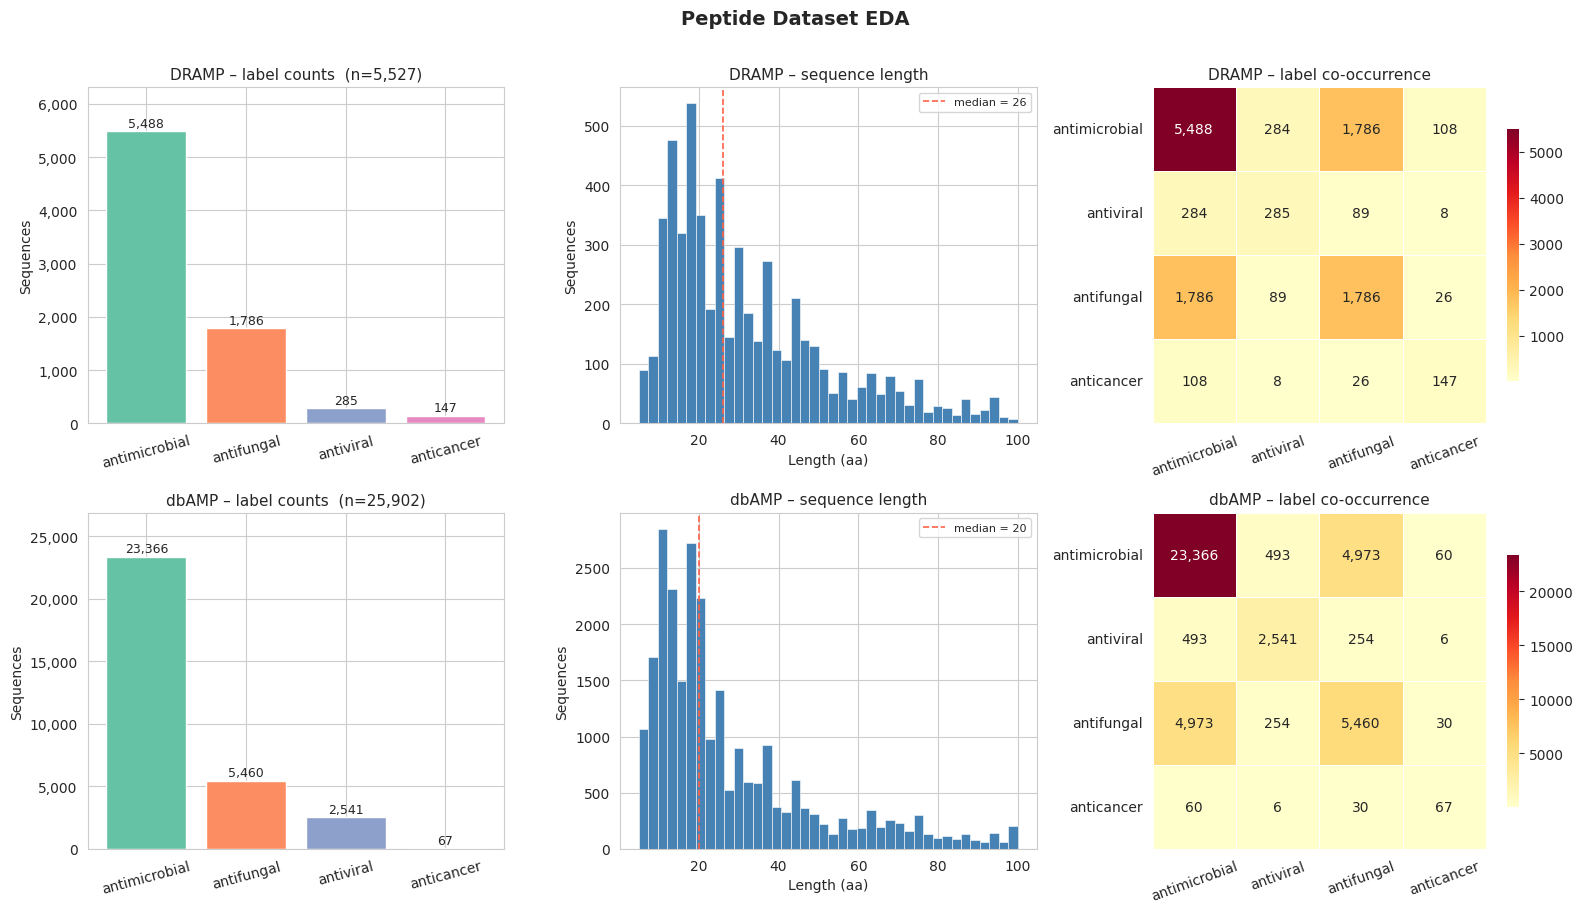

In [50]:
def plot_dataset(df: pd.DataFrame, name: str, ax_counts, ax_len, ax_co) -> None:
    """Three sub-plots for one dataset: label counts, length distribution, label co-occurrence."""
    total = len(df)
    counts = df[LABEL_COLS].sum().sort_values(ascending=False)

    # --- label counts ---
    bars = ax_counts.bar(counts.index, counts.values,
                         color=sns.color_palette('Set2', len(LABEL_COLS)))
    ax_counts.set_title(f'{name} – label counts  (n={total:,})', fontsize=11)
    ax_counts.set_ylabel('Sequences')
    ax_counts.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar, val in zip(bars, counts.values):
        ax_counts.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                       f'{val:,}', ha='center', va='bottom', fontsize=9)
    ax_counts.set_ylim(0, counts.max() * 1.15)
    ax_counts.tick_params(axis='x', rotation=15)

    # --- length distribution ---
    lengths = df['sequence'].str.len()
    ax_len.hist(lengths, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax_len.set_title(f'{name} – sequence length', fontsize=11)
    ax_len.set_xlabel('Length (aa)')
    ax_len.set_ylabel('Sequences')
    ax_len.axvline(lengths.median(), color='tomato', linestyle='--', linewidth=1.2,
                   label=f'median = {lengths.median():.0f}')
    ax_len.legend(fontsize=8)

    # --- label co-occurrence heatmap ---
    co = df[LABEL_COLS].T.dot(df[LABEL_COLS])  # symmetric co-occurrence matrix
    mask = pd.DataFrame(False, index=LABEL_COLS, columns=LABEL_COLS)
    # Don't mask anything – show diagonal too (counts per label)
    sns.heatmap(
        co, ax=ax_co,
        annot=True, fmt=',d', cmap='YlOrRd',
        linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.75},
    )
    ax_co.set_title(f'{name} – label co-occurrence', fontsize=11)
    ax_co.tick_params(axis='x', rotation=20)
    ax_co.tick_params(axis='y', rotation=0)


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.set_style('whitegrid')

plot_dataset(dramp_df, 'DRAMP', *axes[0])
plot_dataset(dbamp_df, 'dbAMP', *axes[1])

plt.suptitle('Peptide Dataset EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [51]:
import hashlib, datetime


def save_csv(df: pd.DataFrame, name: str, out_dir: str) -> str:
    """Save *df* as a CSV, print a confirmation line, and return the file path."""
    filename = f'peptide_data_{name}.csv'
    filepath = os.path.join(out_dir, filename)
    df.to_csv(filepath, index=False)

    size_kb = os.path.getsize(filepath) / 1024
    md5 = hashlib.md5(open(filepath, 'rb').read()).hexdigest()
    ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    print(f'     {filename}')
    print(f'     rows : {len(df):,}')
    print(f'     size : {size_kb:.1f} KB')
    print(f'     md5  : {md5}')
    print(f'     saved: {ts}')
    print(f'     path : {filepath}')
    return filepath


print(f'Saving to {processed_path}\n')
dramp_csv_path = save_csv(dramp_df, 'dramp', processed_path)
print()
dbamp_csv_path = save_csv(dbamp_df, 'dbamp', processed_path)
print('\nDone. Both files are now in your Google Drive.')

Saving to /content/drive/MyDrive/peptide_data/processed

     peptide_data_dramp.csv
     rows : 5,527
     size : 222.2 KB
     md5  : 2d78856ac2670e530e2cb0ccf5339580
     saved: 2026-04-01 17:23:19
     path : /content/drive/MyDrive/peptide_data/processed/peptide_data_dramp.csv

     peptide_data_dbamp.csv
     rows : 25,902
     size : 930.1 KB
     md5  : 11884ba4bfd78bb175e70593f303867c
     saved: 2026-04-01 17:23:19
     path : /content/drive/MyDrive/peptide_data/processed/peptide_data_dbamp.csv

Done. Both files are now in your Google Drive.


In [52]:
print('=== Verification round-trip ===')
for path, name in [(dramp_csv_path, 'DRAMP'), (dbamp_csv_path, 'dbAMP')]:
    df_check = pd.read_csv(path)
    assert list(df_check.columns) == ['sequence'] + LABEL_COLS, 'Column mismatch!'
    assert df_check['sequence'].is_unique, 'Duplicate sequences detected!'
    assert df_check[LABEL_COLS].isin([0, 1]).all().all(), 'Labels are not binary!'
    print(f'    {name}: {len(df_check):,} rows  ·  all assertions passed')

print('\nAll checks passed')

=== Verification round-trip ===
    DRAMP: 5,527 rows  ·  all assertions passed
    dbAMP: 25,902 rows  ·  all assertions passed

All checks passed


## MMseqs2 Sequence-Identity Split


In [53]:
import subprocess, os, sys

MMSEQS_BIN = '/usr/local/bin/mmseqs'


def _run(cmd, **kwargs):
    """Run a shell command and raise on failure."""
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, **kwargs)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f'Command failed: {cmd}')
    return result.stdout


if not os.path.isfile(MMSEQS_BIN):
    print('Downloading MMseqs2 …')
    _run('wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz -O /tmp/mmseqs.tar.gz')
    _run('tar -xzf /tmp/mmseqs.tar.gz -C /tmp')
    _run('cp /tmp/mmseqs/bin/mmseqs /usr/local/bin/mmseqs')
    _run('chmod +x /usr/local/bin/mmseqs')
    print('MMseqs2 installed.')
else:
    print('MMseqs2 already present.')

print(_run('mmseqs version').strip())


MMseqs2 installed.
76da68ad7577378410c075049e18666fcc94f8d1


In [55]:
import tempfile, shutil, math, hashlib, datetime
import numpy as np

RANDOM_SEED = 42

SEQ_ID = 0.40  # 40% sequence identity threshold
COVERAGE = 0.80  # 80

TRAIN_FRAC = 0.80
VAL_FRAC = 0.10


def df_to_fasta(df: 'pd.DataFrame', fasta_path: str) -> None:
    """Write sequence column of *df* to a FASTA file."""
    with open(fasta_path, 'w') as fh:
        for i, seq in enumerate(df['sequence']):
            fh.write(f'>seq{i}\n{seq}\n')


def run_mmseqs_cluster(fasta_in: str, work_dir: str) -> dict:
    """
    Run MMseqs2 easy-cluster and return a dict:
        { representative_seq : [member_seq, …], … }
    """
    prefix = os.path.join(work_dir, 'cluster')
    tmp_dir = os.path.join(work_dir, 'tmp')
    os.makedirs(tmp_dir, exist_ok=True)

    cmd = (
        f'mmseqs easy-cluster {fasta_in} {prefix} {tmp_dir}'
        f' --min-seq-id {SEQ_ID}'
        f' --cov-mode 0 -c {COVERAGE}'
        f'  --cluster-mode 0'  # greedy set cover
        f'  -v 1'  # quiet
    )
    _run(cmd)

    # Parse the cluster TSV (rep\tmember)
    tsv = prefix + '_cluster.tsv'
    clusters: dict = {}
    with open(tsv) as fh:
        for line in fh:
            rep, member = line.strip().split('\t')
            clusters.setdefault(rep, []).append(member)

    return clusters


def assign_clusters_to_splits(
        clusters: dict,
        train_frac: float = TRAIN_FRAC,
        val_frac: float = VAL_FRAC,
        seed: int = RANDOM_SEED,
) -> dict:
    """
    Randomly assign each cluster (by its representative) to
    train / val / test.  Returns {seq_id: split_name}.
    """
    rng = np.random.default_rng(seed)
    reps = list(clusters.keys())
    rng.shuffle(reps)

    n = len(reps)
    n_train = math.floor(n * train_frac)
    n_val = math.floor(n * val_frac)

    assignment = {}
    for i, rep in enumerate(reps):
        if i < n_train:
            split = 'train'
        elif i < n_train + n_val:
            split = 'val'
        else:
            split = 'test'
        for member in clusters[rep]:
            assignment[member] = split

    return assignment  # {seq_fasta_id: 'train'|'val'|'test'}


def mmseqs2_split(
        df: 'pd.DataFrame',
        name: str,
) -> 'dict[str, pd.DataFrame]':
    """
    Full pipeline: cluster *df* with MMseqs2 → assign clusters → return split DataFrames.
    Returns {'train': df_train, 'val': df_val, 'test': df_test}.
    """
    print(f'\n{"─" * 60}')
    print(f'  MMseqs2 split  ·  {name}  ({len(df):,} sequences)')
    print(f'{"─" * 60}')

    with tempfile.TemporaryDirectory() as work_dir:
        fasta_path = os.path.join(work_dir, f'{name}.fasta')
        df_to_fasta(df, fasta_path)

        print('  Running MMseqs2 easy-cluster …', end='', flush=True)
        clusters = run_mmseqs_cluster(fasta_path, work_dir)
        print(f'  done  ({len(clusters):,} clusters found)')

    # Map FASTA IDs (seq0, seq1, …) to split labels
    assignment = assign_clusters_to_splits(clusters)

    # Build split DataFrames using original df index
    df_indexed = df.reset_index(drop=True).copy()
    df_indexed['_fasta_id'] = [f'seq{i}' for i in range(len(df_indexed))]
    df_indexed['_split'] = df_indexed['_fasta_id'].map(assignment)

    splits = {}
    for split_name in ('train', 'val', 'test'):
        sub = (
            df_indexed[df_indexed['_split'] == split_name]
            .drop(columns=['_fasta_id', '_split'])
            .reset_index(drop=True)
        )
        splits[split_name] = sub
        pct = 100 * len(sub) / len(df)
        print(f'  {split_name:<6}  {len(sub):>7,} seqs  ({pct:.1f} %)')

    return splits


def save_split_csv(df: 'pd.DataFrame', filepath: str) -> None:
    """Save *df* as CSV and print a short audit line."""
    df.to_csv(filepath, index=False)
    size_kb = os.path.getsize(filepath) / 1024
    md5 = hashlib.md5(open(filepath, 'rb').read()).hexdigest()
    ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    fname = os.path.basename(filepath)
    print(f'  {fname:<25}  {len(df):>7,} rows  {size_kb:7.1f} KB  {md5[:8]}…  {ts}')


print('Helper functions defined.')


Helper functions defined.


In [56]:
dramp_splits = mmseqs2_split(dramp_df, 'dramp')

dbamp_splits = mmseqs2_split(dbamp_df, 'dbamp')



────────────────────────────────────────────────────────────
  MMseqs2 split  ·  dramp  (5,527 sequences)
────────────────────────────────────────────────────────────
  Running MMseqs2 easy-cluster …  done  (2,418 clusters found)
  train     4,562 seqs  (82.5 %)
  val         457 seqs  (8.3 %)
  test        508 seqs  (9.2 %)

────────────────────────────────────────────────────────────
  MMseqs2 split  ·  dbamp  (25,902 sequences)
────────────────────────────────────────────────────────────
  Running MMseqs2 easy-cluster …  done  (11,540 clusters found)
  train    20,698 seqs  (79.9 %)
  val       2,627 seqs  (10.1 %)
  test      2,577 seqs  (9.9 %)


DRAMP  (total 5,527)
  train :   4,562  (82.5 %)
  val   :     457  (8.3 %)
  test  :     508  (9.2 %)

dbAMP  (total 25,902)
  train :  20,698  (79.9 %)
  val   :   2,627  (10.1 %)
  test  :   2,577  (9.9 %)



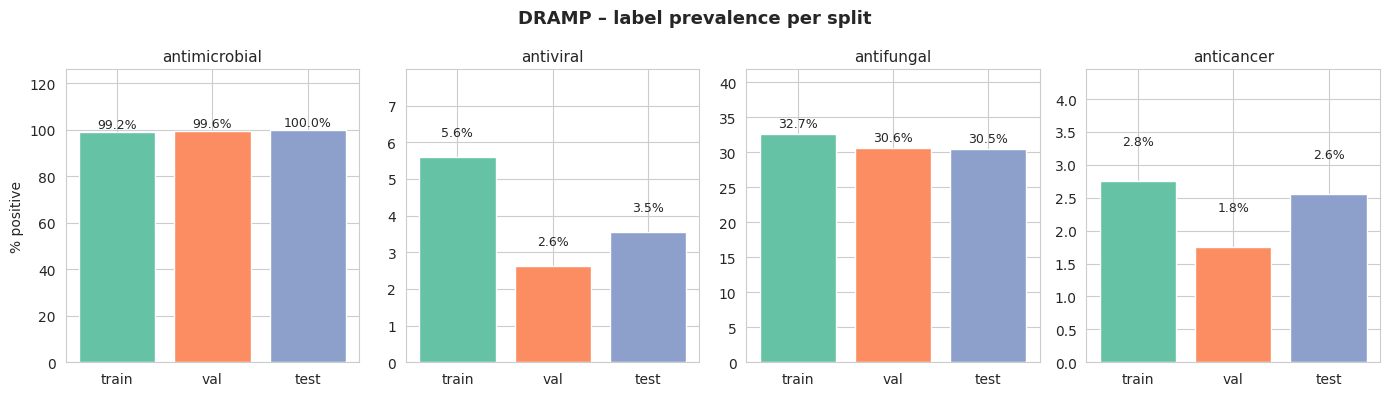

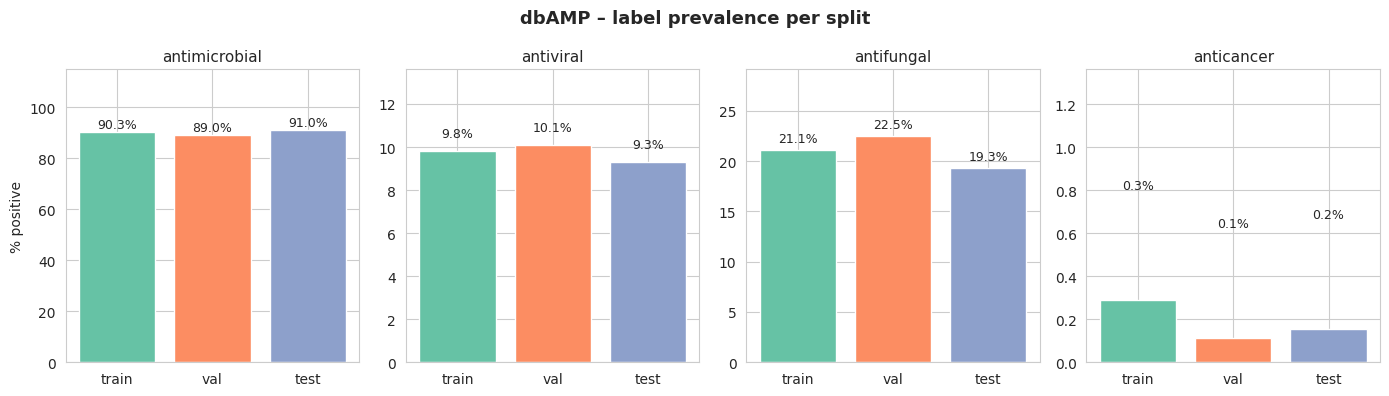

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
LABEL_COLS = ['antimicrobial', 'antiviral', 'antifungal', 'anticancer']


def plot_split_summary(splits: dict, name: str) -> None:
    """Bar chart of label prevalence per split for one source dataset."""
    split_names = ['train', 'val', 'test']
    colors = sns.color_palette('Set2', 3)

    fig, axes = plt.subplots(1, len(LABEL_COLS), figsize=(14, 4), sharey=False)
    fig.suptitle(f'{name} – label prevalence per split', fontsize=13, fontweight='bold')

    for ax, label in zip(axes, LABEL_COLS):
        vals = [splits[s][label].mean() * 100 for s in split_names]
        bars = ax.bar(split_names, vals, color=colors)
        ax.set_title(label, fontsize=11)
        ax.set_ylabel('% positive') if label == LABEL_COLS[0] else None
        ax.set_ylim(0, max(vals) * 1.25 + 1)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


# Print size summary
for name, splits in [('DRAMP', dramp_splits), ('dbAMP', dbamp_splits)]:
    total = sum(len(v) for v in splits.values())
    print(f'{name}  (total {total:,})')
    for split_name, sub in splits.items():
        print(f'  {split_name:<6}: {len(sub):>7,}  ({100 * len(sub) / total:.1f} %)')
    print()

plot_split_summary(dramp_splits, 'DRAMP')
plot_split_summary(dbamp_splits, 'dbAMP')


In [61]:
print(f'Saving split CSVs to {processed_path}\n')

for source_name, splits in [('dramp', dramp_splits), ('dbamp', dbamp_splits)]:
    for split_name, df_split in splits.items():
        filepath = os.path.join(processed_path, f'{source_name}_{split_name}.csv')
        save_split_csv(df_split, filepath)

print('\nAll six split CSVs saved to Google Drive')


Saving split CSVs to /content/drive/MyDrive/peptide_data/processed

  dramp_train.csv              4,562 rows    183.8 KB  e1d2b8b2…  2026-04-01 17:25:06
  dramp_val.csv                  457 rows     17.5 KB  7d092e88…  2026-04-01 17:25:06
  dramp_test.csv                 508 rows     21.0 KB  e50cd2de…  2026-04-01 17:25:06
  dbamp_train.csv             20,698 rows    747.1 KB  dcb2bf03…  2026-04-01 17:25:06
  dbamp_val.csv                2,627 rows     97.8 KB  4b268653…  2026-04-01 17:25:06
  dbamp_test.csv               2,577 rows     85.3 KB  ef419eae…  2026-04-01 17:25:06

All six split CSVs saved to Google Drive
